<a href="https://colab.research.google.com/github/stephanie465337/Data-Science-Portfolio-C21/blob/main/Projects/Project-4/Spotify_Pass_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Project 4: Music Popularity Prediction


This project will take data features collected for songs that have been on the Top 200 Weekly (Global) charts of Spotify in 2020 & 2021. The popularity of the song will be predicted using a tree-based regression model trained on these features.



The goals for the project are:

- Minimize the cross-validated ***root mean squared error ( RMSE )*** when predicting the popularity of a new song.

- Determine the importance of the features in driving the regression result.
The project will be done using tree-based regression techniques as covered in class. The hyperparameters of the trees should be carefully selected to avoid over-fitting.


There are three main challenges for this project:

1. Determining the outcome ( i.e. target ).  There is a "popularity" column.  But other columns may or may not be more appropriate indicators of popularity.

1. Choosing appropriate predictors ( i.e. features ). When building a machine learning model, we want to make sure that we consider how the model will be ultimately used. For this project, we are predicting the popularity of a new song. Therefore, we should only include the predictors we would have for a new song. It might help to imagine that the song will not be released for several weeks.

1. Data cleaning and feature engineering. Some creative cleaning and/or feature engineering may be needed to extract useful information for prediction.



Once again, be sure to go through the whole data science process and document as such in your Jupyter notebook.

The data is available on AWS S3 at https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv .



##Problem Definition
Understand the project's objectives from a business viewpoint.

- What is the Business Problem?  Often some variant of saving time, saving money, and/or making money.
*Which songs will be popular*
- What Data Science Problem is this? ( *Supervised* or Unsupervised )
- If Supervised ...
  - How did you determine what is the target? What is the Target?
  - What statistical data type is the target: Numerical or Categorical?
  - Would this be a Classification or a *Regression* problem?
- If Unsupervised ...
  - What kind of clustering problem?

'This is a **Supervised** **Regression** problem and we'll be using the tree-based regression model to make the predictions on how **popular** a song will be. We'll also be using Random Forest and XGBoost ***regularization techniques to reduce overfitting and for feature selection.*** Our performance metric will be Cross-validated Root Mean Squared Error (**RMSE**).'

##Data Collection
Gather relevant data. If data are already available, understand how data were collected.

- Where is the data source located: local file, database, website, API, other?
- Where is the data dictionary?
- How many bytes ( KB, MB, GB, TB ) is the data set?
- What tools did/would you use to get and read the data?

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
#Set the URL
url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv"
url

'https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv'

In [ ]:
df = pd.read_csv(url)
df

,Index,Highest Charting Position,Number of Times Charted,Week of Highest Charting,Song Name,Streams,Artist,Artist Followers,Song ID,Genre,...,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence,Chord
0,1,1,8,2021-07-23--2021-07-30,Beggin',"48,633,449",Måneskin,3377762,3Wrjm47oTz2sjIgck11l5e,"['indie rock italiano', 'italian pop']",...,0.714,0.8,-4.808,0.0504,0.127,0.359,134.002,211560,0.589,B
1,2,2,3,2021-07-23--2021-07-30,STAY (with Justin Bieber),"47,248,719",The Kid LAROI,2230022,5HCyWlXZPP0y6Gqq8TgA20,['australian hip hop'],...,0.591,0.764,-5.484,0.0483,0.0383,0.103,169.928,141806,0.478,C#/Db
2,3,1,11,2021-06-25--2021-07-02,good 4 u,"40,162,559",Olivia Rodrigo,6266514,4ZtFanR9U6ndgddUvNcjcG,['pop'],...,0.563,0.664,-5.044,0.154,0.335,0.0849,166.928,178147,0.688,A
3,4,3,5,2021-07-02--2021-07-09,Bad Habits,"37,799,456",Ed Sheeran,83293380,6PQ88X9TkUIAUIZJHW2upE,"['pop', 'uk pop']",...,0.808,0.897,-3.712,0.0348,0.0469,0.364,126.026,231041,0.591,B
4,5,5,1,2021-07-23--2021-07-30,INDUSTRY BABY (feat. Jack Harlow),"33,948,454",Lil Nas X,5473565,27NovPIUIRrOZoCHxABJwK,"['lgbtq+ hip hop', 'pop rap']",...,0.736,0.704,-7.409,0.0615,0.0203,0.0501,149.995,212000,0.894,D#/Eb
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1551,1552,195,1,2019-12-27--2020-01-03,New Rules,"4,630,675",Dua Lipa,27167675,2ekn2ttSfGqwhhate0LSR0,"['dance pop', 'pop', 'uk pop']",...,0.762,0.7,-6.021,0.0694,0.00261,0.153,116.073,209320,0.608,A
1552,1553,196,1,2019-12-27--2020-01-03,Cheirosa - Ao Vivo,"4,623,030",Jorge & Mateus,15019109,2PWjKmjyTZeDpmOUa3a5da,"['sertanejo', 'sertanejo universitario']",...,0.528,0.87,-3.123,0.0851,0.24,0.333,152.37,181930,0.714,B
1553,1554,197,1,2019-12-27--2020-01-03,Havana (feat. Young Thug),"4,620,876",Camila Cabello,22698747,1rfofaqEpACxVEHIZBJe6W,"['dance pop', 'electropop', 'pop', 'post-teen ...",...,0.765,0.523,-4.333,0.03,0.184,0.132,104.988,217307,0.394,D
1554,1555,198,1,2019-12-27--2020-01-03,Surtada - Remix Brega Funk,"4,607,385","Dadá Boladão, Tati Zaqui, OIK",208630,5F8ffc8KWKNawllr5WsW0r,"['brega funk', 'funk carioca']",...,0.832,0.55,-7.026,0.0587,0.249,0.182,154.064,152784,0.881,F


In [ ]:
#Look at the headers
!curl -s -I {url}

HTTP/1.1 200 OK
x-amz-id-2: 0Rd2C5qDs5xPzC+hjnl4iSXZtz7ikRtwHWADJ7HBDeLMuBX8OfjLOZxUacYliT/L+9Y4tiSnAvI=
x-amz-request-id: BRZZPN0DD7RY1B72
Date: Sat, 11 Jul 2026 18:25:44 GMT
Last-Modified: Wed, 04 Oct 2023 17:23:56 GMT
ETag: "65b9875b11e0d7ea03ee2af024f45e99"
x-amz-server-side-encryption: AES256
Accept-Ranges: bytes
Content-Type: text/csv
Content-Length: 738124
Server: AmazonS3



In [ ]:
#Download the file
!curl -s -O {url}

In [ ]:
#Verify
!ls -la

total 740
drwxr-xr-x 1 root root   4096 Jul 11 18:14 .
drwxr-xr-x 1 root root   4096 Jul 11 17:19 ..
drwxr-xr-x 4 root root   4096 Jun  4 13:32 .config
drwxr-xr-x 1 root root   4096 Jun  4 13:32 sample_data
-rw-r--r-- 1 root root 738124 Jul 11 18:25 Spotify.csv


In [ ]:
#Look at the field names
!head -1 Spotify.csv | tr , '\n' | cat -n

     1	Index
     2	Highest Charting Position
     3	Number of Times Charted
     4	Week of Highest Charting
     5	Song Name
     6	Streams
     7	Artist
     8	Artist Followers
     9	Song ID
    10	Genre
    11	Release Date
    12	Weeks Charted
    13	Popularity
    14	Danceability
    15	Energy
    16	Loudness
    17	Speechiness
    18	Acousticness
    19	Liveness
    20	Tempo
    21	Duration (ms)
    22	Valence
    23	Chord


##Data Cleaning

- How can/did you discover how many rows?
- How can/did you discover how many columns?
- How can/did you discover if there are any unique identifiers and how would/did you handle them?
- How can/did you discover if there are any nulls and how would/did you handle them?
- If Supervised, how can/did you discover if there are any nulls in your target and how would/did you handle them?
- How can/did you discover if there are any duplicates and how would/did you handle them?
- How can/did you discover if there are any missing values and how would/did you handle them?
- How can/did you discover if there are any nested fields and how would/did you handle them?

In [ ]:
df.shape

(1556, 23)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1556 entries, 0 to 1555
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Index                      1556 non-null   int64 
 1   Highest Charting Position  1556 non-null   int64 
 2   Number of Times Charted    1556 non-null   int64 
 3   Week of Highest Charting   1556 non-null   object
 4   Song Name                  1556 non-null   object
 5   Streams                    1556 non-null   object
 6   Artist                     1556 non-null   object
 7   Artist Followers           1556 non-null   object
 8   Song ID                    1556 non-null   object
 9   Genre                      1556 non-null   object
 10  Release Date               1556 non-null   object
 11  Weeks Charted              1556 non-null   object
 12  Popularity                 1556 non-null   object
 13  Danceability               1556 non-null   object
 14  Energy  

In [ ]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Index,1556.0,778.500000,449.322824,1.0,389.75,778.5,1167.25,1556.0
Highest Charting Position,1556.0,87.744216,58.147225,1.0,37.00,80.0,137.00,200.0
Number of Times Charted,1556.0,10.668380,16.360546,1.0,1.00,4.0,12.00,142.0


In [ ]:
df.isnull().sum()*1000

,0
Index,0
Highest Charting Position,0
Number of Times Charted,0
Week of Highest Charting,0
Song Name,0
Streams,0
Artist,0
Artist Followers,0
Song ID,0
Genre,0


###Target

In [ ]:
target = 'Highest Charting Position'

In [ ]:
#View target
df[target]

,Highest Charting Position
0,1
1,2
2,1
3,3
4,5
...,...
1551,195
1552,196
1553,197
1554,198


In [ ]:
#Look to see if there are nulls in target
df[target].isnull().sum()

np.int64(0)

In [ ]:
#Check the dtype
df[target].dtype

dtype('int64')

In [ ]:
df[target].describe().transpose()

,Highest Charting Position
count,1556.000000
mean,87.744216
std,58.147225
min,1.000000
25%,37.000000
50%,80.000000
75%,137.000000
max,200.000000


###Rows

In [ ]:
#Rows with nulls
df.isnull().any(axis = 1).sum()

np.int64(0)

In [ ]:
#Missing rows
df.isnull().sum().sort_values()

,0
Index,0
Highest Charting Position,0
Number of Times Charted,0
Week of Highest Charting,0
Song Name,0
Streams,0
Artist,0
Artist Followers,0
Song ID,0
Genre,0


In [ ]:
#Duplicate rows
df.duplicated().sum()

np.int64(0)

###Columns

In [ ]:
df.dtypes.value_counts()

,count
object,20
int64,3


In [ ]:
df_int = df.select_dtypes(include=['int64']) #64 subject to change
df_int

,Index,Highest Charting Position,Number of Times Charted
0,1,1,8
1,2,2,3
2,3,1,11
3,4,3,5
4,5,5,1
...,...,...,...
1551,1552,195,1
1552,1553,196,1
1553,1554,197,1
1554,1555,198,1


In [ ]:
df_int = df_int.drop(columns=['Index', target])
df_int

,Number of Times Charted
0,8
1,3
2,11
3,5
4,1
...,...
1551,1
1552,1
1553,1
1554,1


##Exploratory Data Analysis (EDA)

- If Supervised, what data type is your target?  What does that suggest for the type of ML process you will use?
- What is the distribution of values for your target?
- How can/did you discover which fields are Categorical?
- How can/did you discover which fields are Numerical?
- For each field, what is the distribution?
- How can/did you discover the relationship between any two variables?




In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
feature = 'Number of Times Charted'

###Histogram

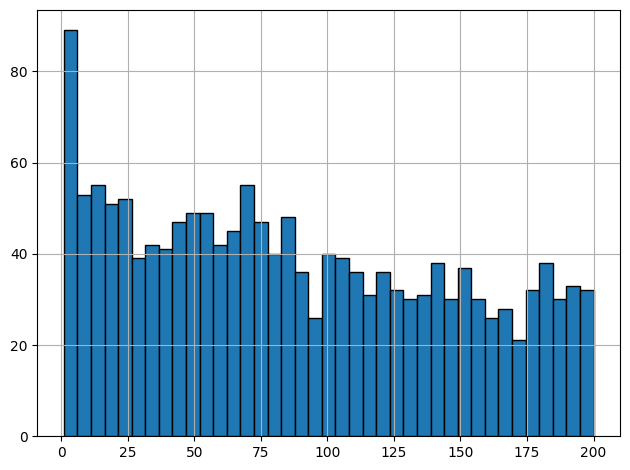

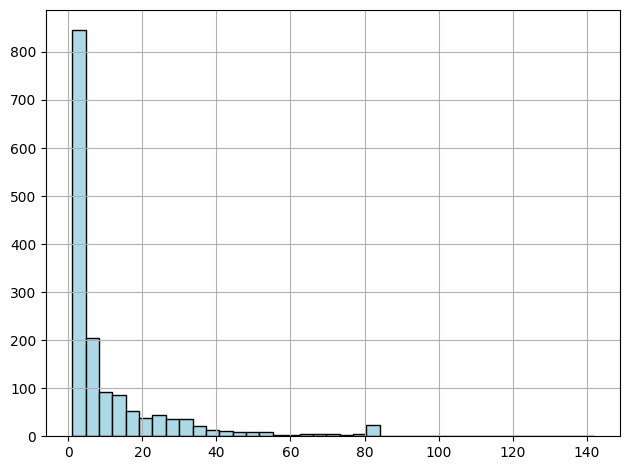

In [ ]:
n = int(1556**(1/2)) # bins

df[target].hist(bins=n, edgecolor='black')

plt.tight_layout()
plt.show()

df[feature].hist(bins=n, color='lightblue', edgecolor='black')

plt.tight_layout()
plt.show()

###Boxplot

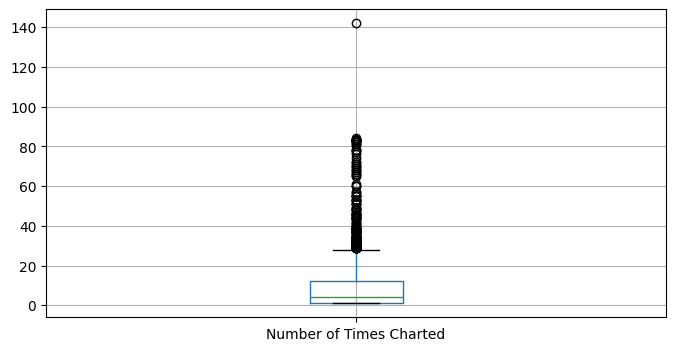

In [ ]:
plt.figure(figsize=(8,4))

df.boxplot(column='Number of Times Charted')
plt.show()

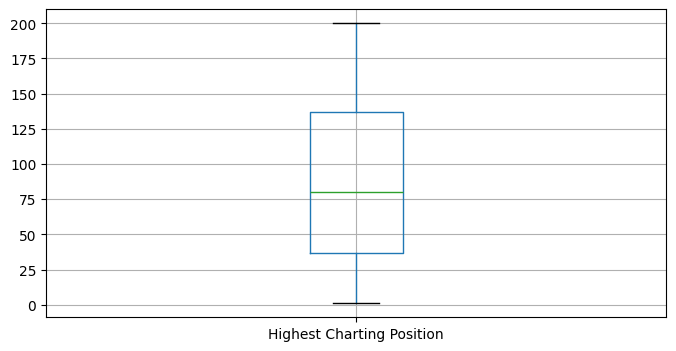

In [ ]:
plt.figure(figsize=(8,4))

df.boxplot(column='Highest Charting Position')
plt.show()

##Processing
Use modeling techniques to gain useful insights into data and meet objectives of the project.

- What questions did you ask to determine which ML process to use?
- How did/can you determine what performance metric to use?  What others could you have used?  Which metrics might not be appropriate?
- How did/can you account for the variance/bias trade-off?

Models we've learned so far:
- Naive Bayes
- Gaussian Naive Bayes
- Linear Regession
- Ridge Regulation
- Lasso Regulation

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn import datasets
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

###Decision Tree Regression

In [ ]:
y = df[target]
X = df[[feature]]

In [ ]:
numLoops = 500

rms_error = np.zeros(numLoops)

for idx in range(0,numLoops):
  X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
  model = DecisionTreeRegressor(max_depth=3)         # Arbitrarily choosing max_depth of 3
  model.fit(X_train,y_train)
  y_pred = model.predict(X_test)
  rms_error[idx] = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"CV RMSE: {rms_error.mean().round(2)*1000}")

CV RMSE: 48540.0


###How do we choose the tree depth?

In [ ]:
max_depths = [1,2,3,4,5,6,7,8,9,10]
rms_depth = np.zeros(len(max_depths))
std_depth = np.zeros(len(max_depths))

numLoops = 500

for n, depth in enumerate(max_depths):
  rms_error = np.zeros(numLoops)

  for idx in range(0,numLoops):
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
    model = DecisionTreeRegressor(max_depth=depth)
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    rms_error[idx] = np.sqrt(mean_squared_error(y_test, y_pred))

  rms_depth[n] = rms_error.mean()
  std_depth[n] = rms_error.std(ddof = 1)

In [ ]:
pd.DataFrame(zip(max_depths, rms_depth, std_depth))

,0,1,2
0,1,50.375125,1.363228
1,2,48.568992,1.435084
2,3,48.336649,1.320129
3,4,48.510126,1.334811
4,5,48.726968,1.365919
5,6,48.775395,1.441982
6,7,48.955308,1.380659
7,8,48.965794,1.339572
8,9,49.210696,1.379671
9,10,49.108322,1.431171


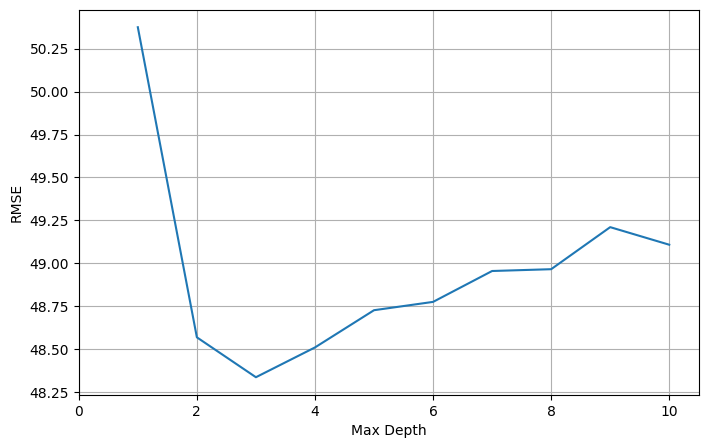

In [ ]:
 #Plot result
plt.figure(figsize = (8,5))
plt.plot(max_depths, rms_depth)
plt.xlabel('Max Depth')
plt.ylabel('RMSE')
plt.xlim(0, 10.5)
plt.grid()

In [ ]:
#Re run with max depth = 4
numLoops = 500

rms_error = np.zeros(numLoops)

for idx in range(0, numLoops):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
  model = DecisionTreeRegressor(max_depth=4)
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  rms_error[idx] = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"CV RMSE: {rms_error.mean().round(2)*1000}")

###Visualize the Decision Tree

In [ ]:
import graphviz
from IPython.display import display
from sklearn import tree

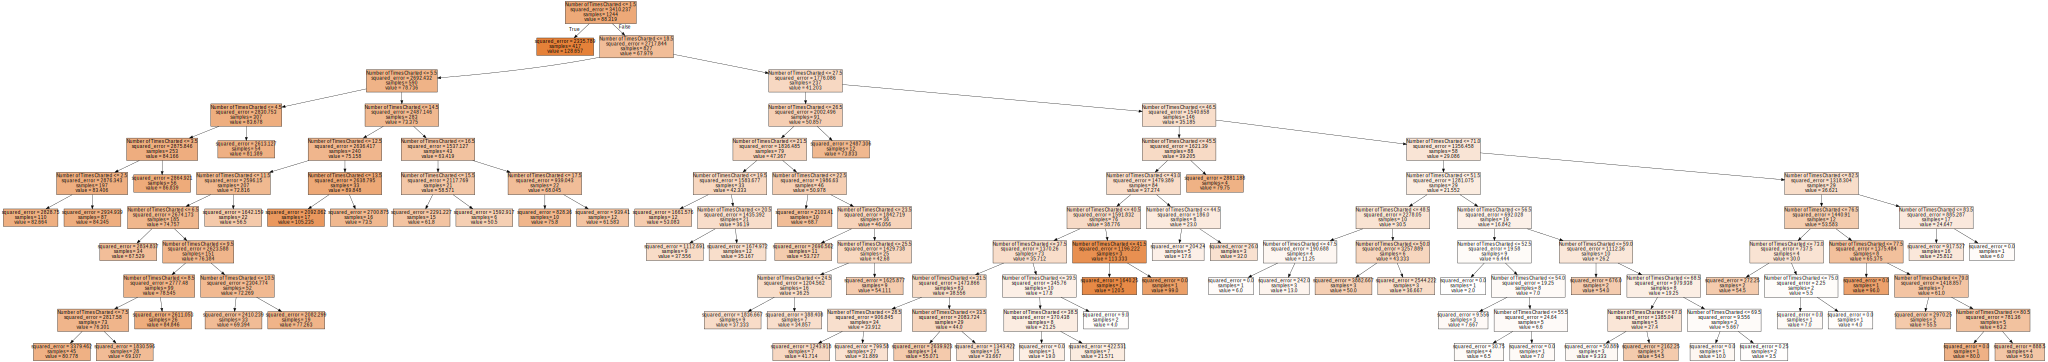

In [ ]:
#Readable view
display(
  graphviz.Source(
    tree.export_graphviz(
      model,
      feature_names = X.columns,
      filled = True,
    )
  )
)

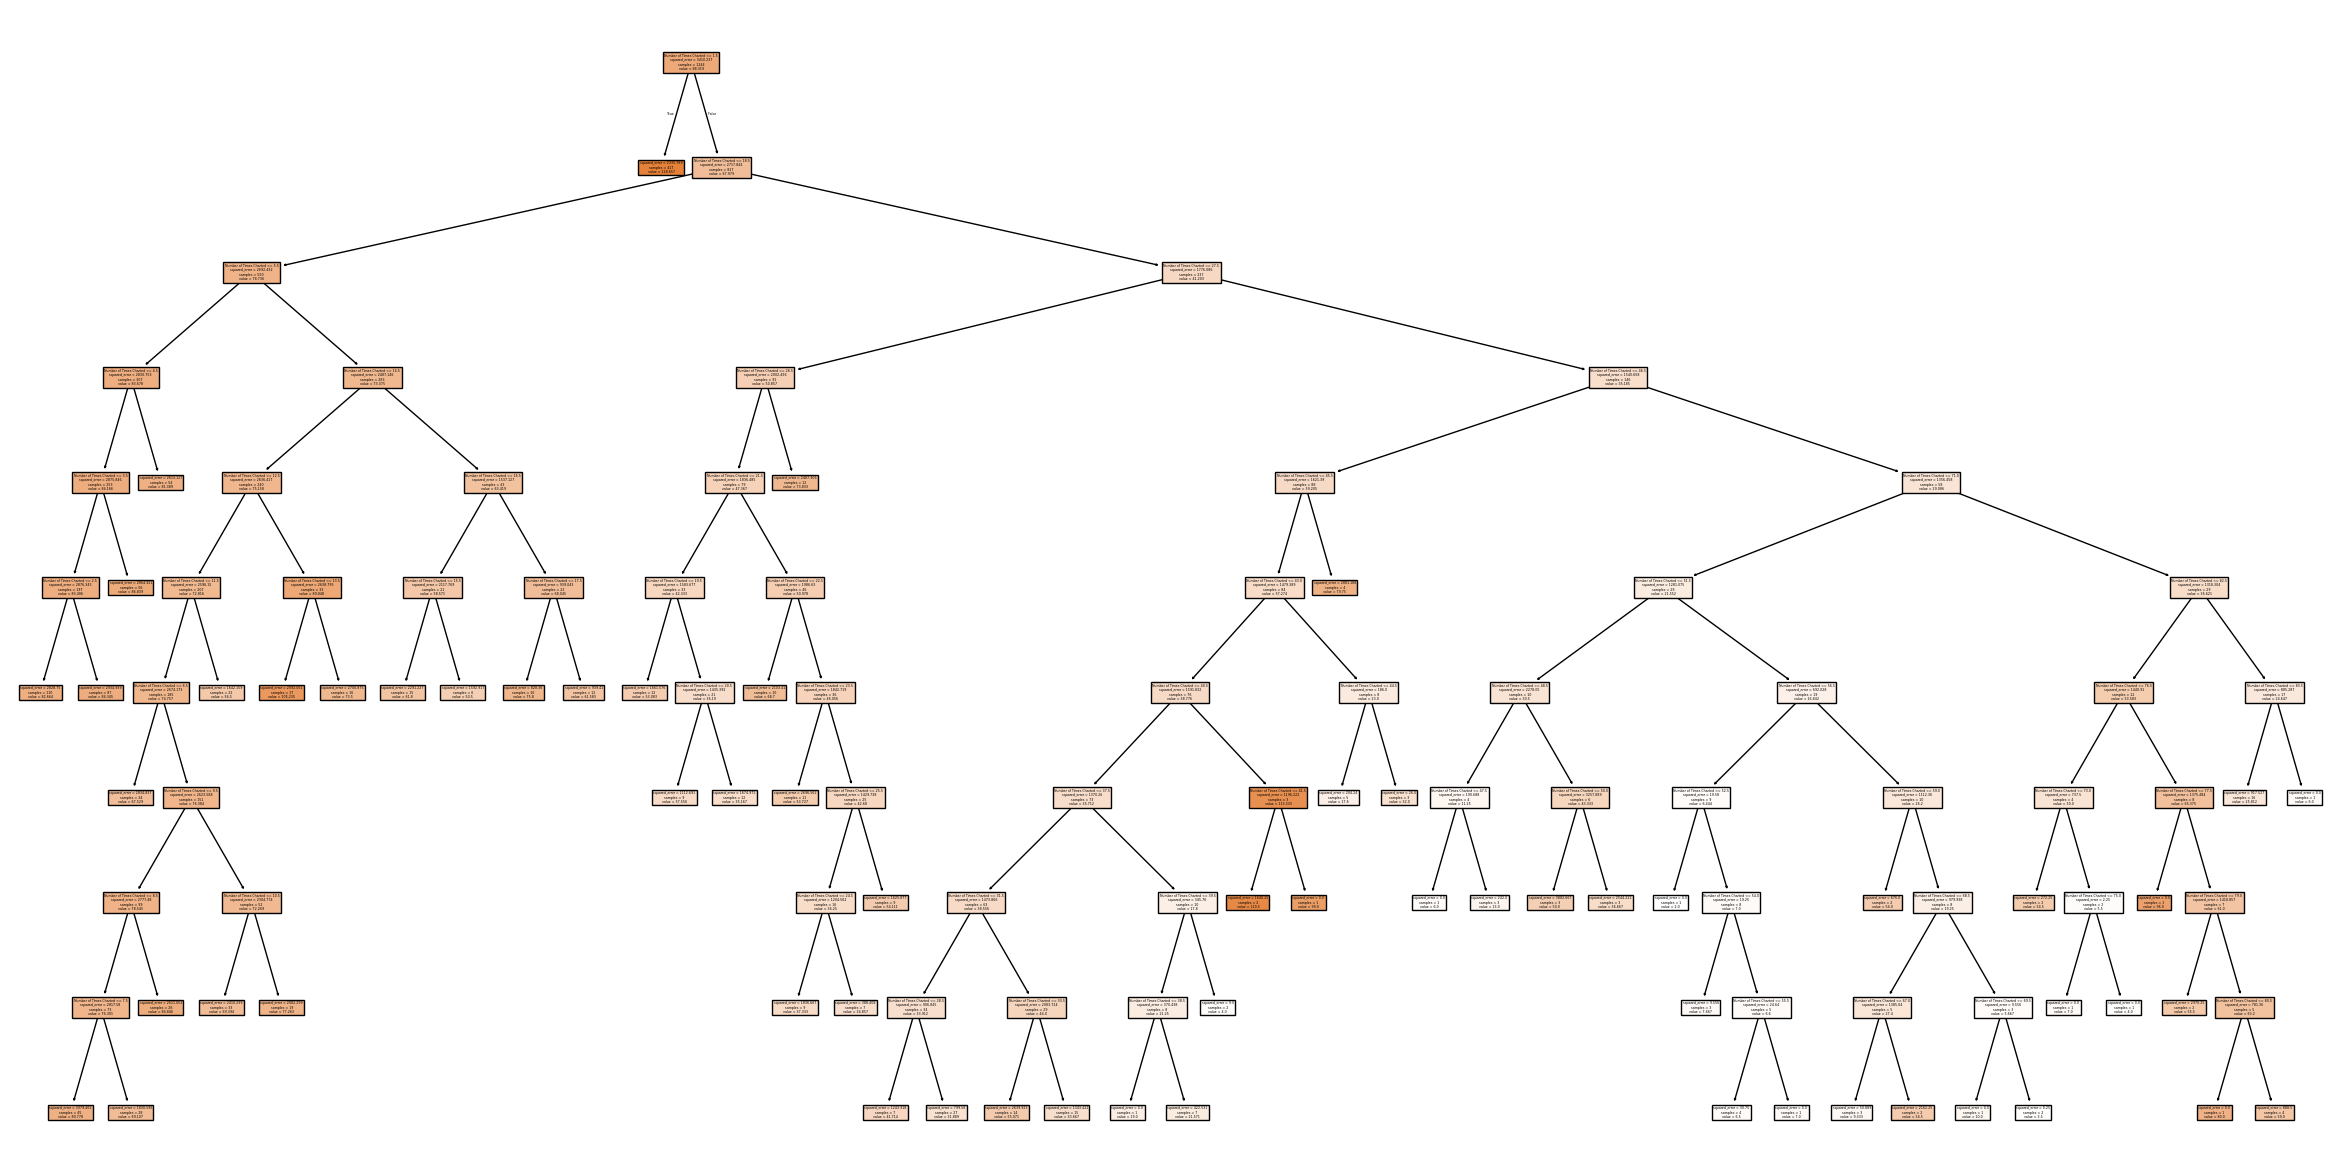

In [ ]:
#Full view
plt.figure(figsize=(30,15))
tree_plot = tree.plot_tree(
  model,
  feature_names = X.columns,
  filled=True,
)

##Conclusion and Future Work

Began this model with the basics and chose one feature.
Selected the target and feature with the two ints available
- Conclusions
  - Not a good model with an RMSE of 48.5
- Future Work
  - Choose a different target
  - test other models RF and XGB
  - Use One-Hot Encodeing for objects